Training (Standard): 100%|██████████| 7000/7000 [00:00<00:00, 54847.27it/s]



=== Standard Linear Regression Parameters ===
Weight (m): 52.74342300713858
Bias (b): -0.33377900609345124

=== Mean Squared Error (Standard Regression) ===
MSE: 110.43782888723496


Training (Ridge): 100%|██████████| 7000/7000 [00:00<00:00, 44986.71it/s]



=== Ridge Regression Parameters ===
Weight (m): 47.62721054836812
Bias (b): -0.43442262735370324

=== Mean Squared Error (Ridge Regression) ===
MSE: 122.2020692168243


Training (Ridge): 100%|██████████| 3000/3000 [00:00<00:00, 43677.32it/s]


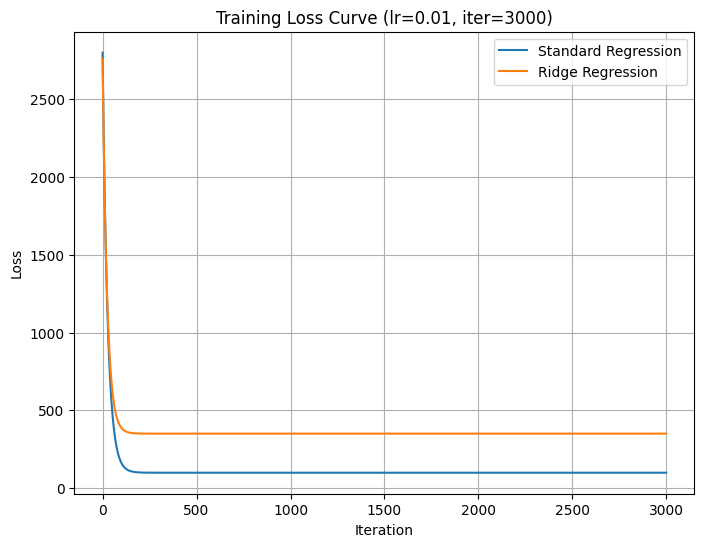

Training (Ridge): 100%|██████████| 7000/7000 [00:00<00:00, 44433.88it/s]


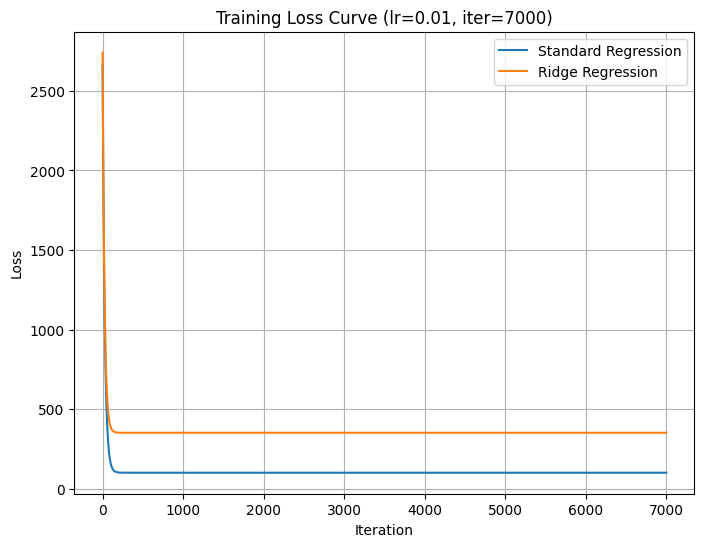

Training (Ridge): 100%|██████████| 3000/3000 [00:00<00:00, 45661.73it/s]


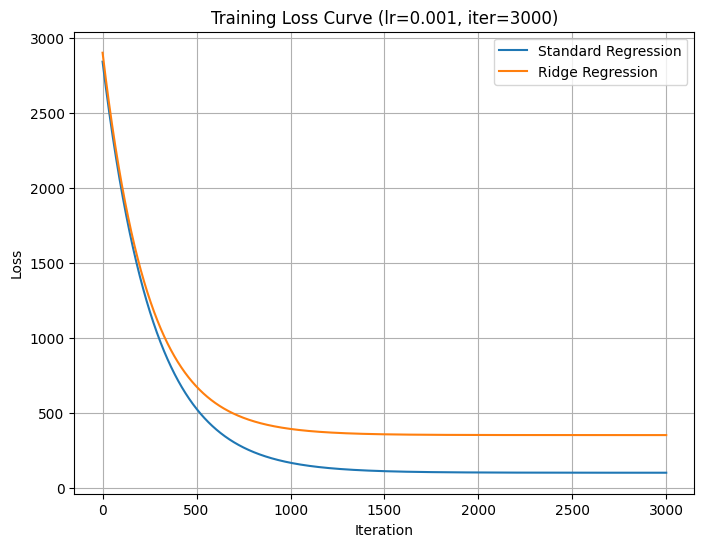

Training (Ridge): 100%|██████████| 7000/7000 [00:00<00:00, 44778.82it/s]


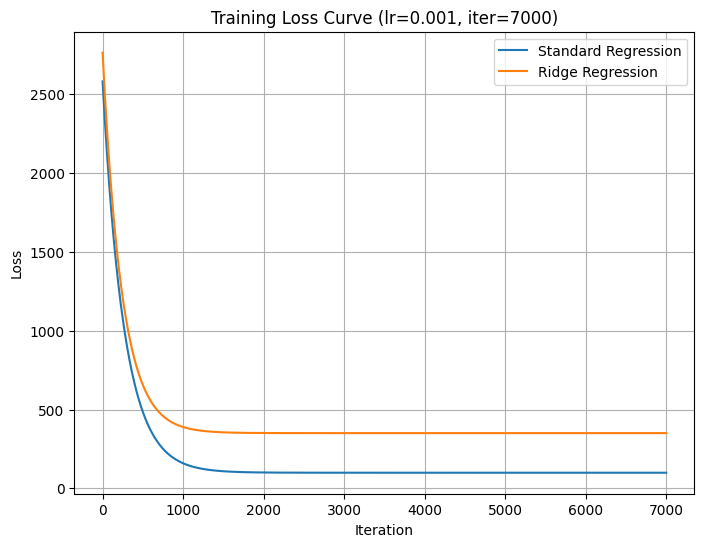

Training (Ridge): 100%|██████████| 3000/3000 [00:00<00:00, 42184.90it/s]


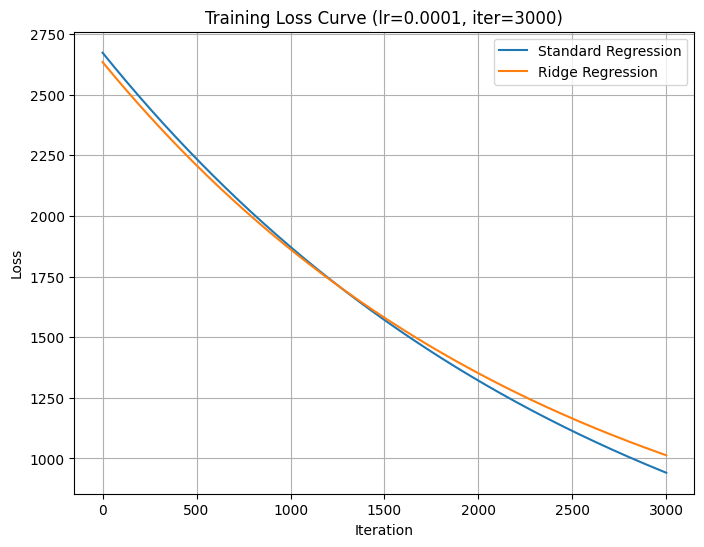

Training (Ridge): 100%|██████████| 7000/7000 [00:00<00:00, 43744.37it/s]


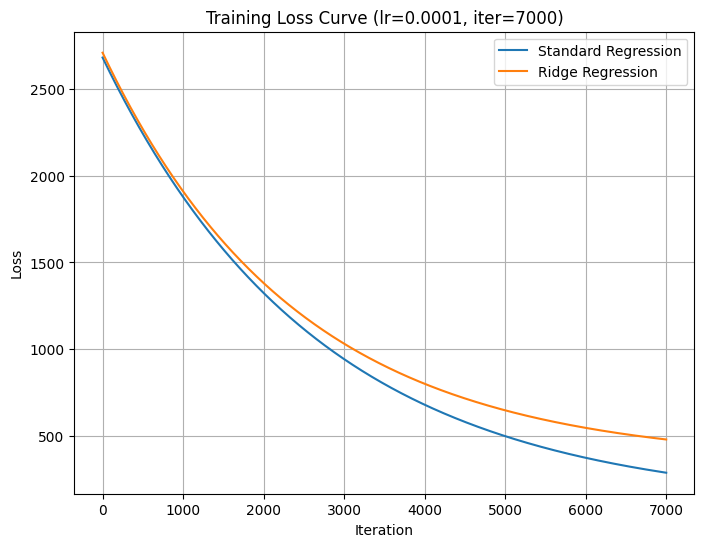


=== Closed-form Ridge Regression Parameters ===
Weight (m): 52.73598792691737
Bias (b): -0.33386296536821514

=== Mean Squared Error (Closed-form Ridge Regression) ===
MSE: 110.41538156212273

=== Predictive Distribution ===
Predictive Mean (first 5 values): [-41.53431739  53.05914752 -44.50052528 -17.520322    -0.79827775]
Predictive Variance: 123.71015891602403


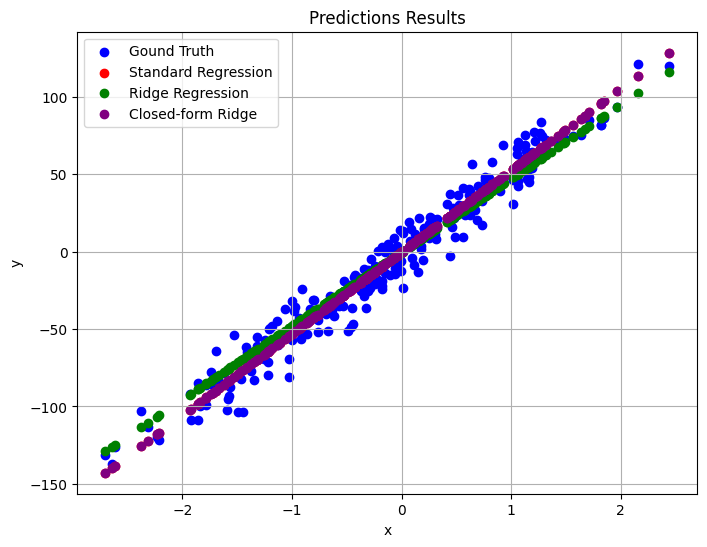

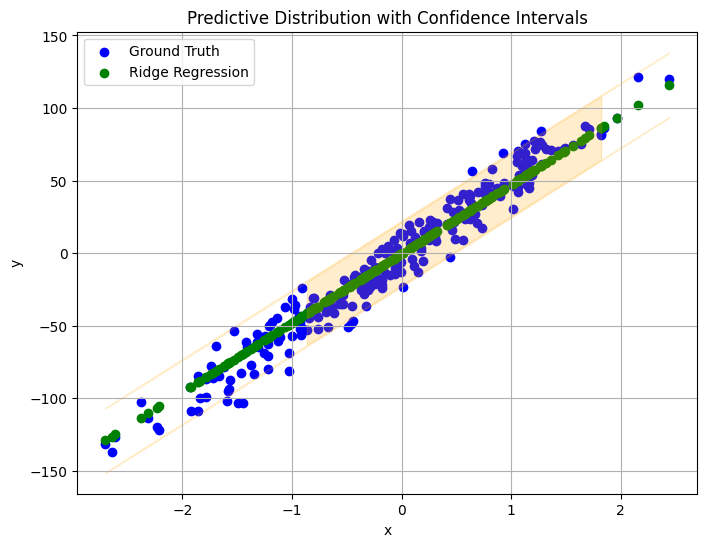

In [1]:
# -*- coding: utf-8 -*-
"""Labs1_Regression_Student.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/15PUOi2c44MB8bhj3d7Ez9thahW83rTHK
"""

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load dataset
x_train, x_test, y_train, y_test = np.load('regression_data.npy', allow_pickle=True)

# Reshape targets
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Add bias term (column of ones)
train_data = np.hstack((x_train, np.ones((x_train.shape[0], 1))))
test_data = np.hstack((x_test, np.ones((x_test.shape[0], 1))))

# ==============================
# Task 1: Standard Linear Regression (Gradient Descent)
# ==============================
def linear_regression_train(x_train, y_train, lr=1e-3, iterations=7000):
    weight = np.random.randn(2)
    loss = np.zeros(iterations)

    for i in tqdm(range(iterations), desc="Training (Standard)"):
        y_pred = x_train @ weight # Compute predicted values

        loss[i] = np.mean((y_pred - y_train) ** 2) # Compute MSE

        # Compute gradients
        m_gradient = (2 / x_train.shape[0]) * ((y_pred - y_train) @ x_train[:, 0])  # Compute gradient for weight
        b_gradient = (2 / x_train.shape[0]) * np.sum(y_pred - y_train)  # Compute gradient for bias

        # Update weights
        weight[0] -= lr * m_gradient  # Apply gradient descent for weight
        weight[1] -= lr * b_gradient  # Apply gradient descent for bias

    return weight, loss

weight_standard, loss_standard = linear_regression_train(train_data, y_train)

print("\n=== Standard Linear Regression Parameters ===")
print(f'Weight (m): {weight_standard[0]}')  # Print weight[0]
print(f'Bias (b): {weight_standard[1]}')  # Print weight[1]

# ==============================
# Task 2: Compute MSE
# ==============================
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)  # Compute MSE formula

y_pred_standard = test_data @ weight_standard  # Compute predictions for test data
mse_standard = compute_mse(y_test, y_pred_standard)

print("\n=== Mean Squared Error (Standard Regression) ===")
print(f'MSE: {mse_standard}')

# ==============================
# Task 3: Ridge Regression (Gradient Descent)
# ==============================
def ridge_regression_train(x_train, y_train, lr=1e-3, iterations=7000, lambda_reg=0.1):
    weight = np.random.randn(2)
    loss = np.zeros(iterations)

    for i in tqdm(range(iterations), desc="Training (Ridge)"):
        y_pred = x_train @ weight  # Compute predicted values

        loss[i] = np.mean((y_pred - y_train) ** 2) + lambda_reg * np.sum(weight ** 2)  # Compute MSE with regularization term

        # Compute gradients with regularization
        m_gradient = (2 / x_train.shape[0]) * ((y_pred - y_train) @ x_train[:, 0]) + 2 * lambda_reg * weight[0]  # Compute weight gradient with regularization
        b_gradient = (2 / x_train.shape[0]) * np.sum(y_pred - y_train)  # Compute bias gradient

        # Update weights
        weight[0] -= lr * m_gradient  # Apply gradient descent for weight
        weight[1] -= lr * b_gradient  # Apply gradient descent for bias

    return weight, loss

weight_ridge, loss_ridge = ridge_regression_train(train_data, y_train)

print("\n=== Ridge Regression Parameters ===")
print(f'Weight (m): {weight_ridge[0]}')
print(f'Bias (b): {weight_ridge[1]}')

y_pred_ridge = test_data @ weight_ridge  # Compute predictions for test data
mse_ridge = compute_mse(y_test, y_pred_ridge)

print("\n=== Mean Squared Error (Ridge Regression) ===")
print(f'MSE: {mse_ridge}')

# ==============================
# Task 4: Plot Loss Curve
# ==============================
learning_rates = [1e-2, 1e-3, 1e-4]
iteration_settings = [3000, 7000]

for lr in learning_rates:
    for iters in iteration_settings:
        # Standard Regression Loss
        _, loss_std_exp = linear_regression_train(train_data, y_train, lr=lr, iterations=iters)
        
        # Ridge Regression Loss
        _, loss_rdg_exp = ridge_regression_train(train_data, y_train, lr=lr, iterations=iters, lambda_reg=0.1)
        
        if np.isnan(loss_std_exp[-1]) or np.isinf(loss_std_exp[-1]):
            continue

        # Plotting the loss curves
        plt.figure(figsize=(8, 6))
        plt.plot(loss_std_exp, label='Standard Regression')
        plt.plot(loss_rdg_exp, label='Ridge Regression')
        plt.title(f'Training Loss Curve (lr={lr}, iter={iters})')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

# ==============================
# Task 5: Closed-form Ridge Regression
# ==============================
def closed_form_ridge(x_train, y_train, lambda_reg=0.1):
    I = np.eye(x_train.shape[1])
    w_closed_form = np.linalg.inv(x_train.T @ x_train + lambda_reg * I) @ x_train.T @ y_train  # Compute closed-form solution (Equation 4.27)
    return w_closed_form

weight_closed_form = closed_form_ridge(train_data, y_train)
y_pred_closed_form = test_data @ weight_closed_form  # Compute predictions for test data
mse_closed_form = compute_mse(y_test, y_pred_closed_form)

print("\n=== Closed-form Ridge Regression Parameters ===")
print(f'Weight (m): {weight_closed_form[0]}')
print(f'Bias (b): {weight_closed_form[1]}')
print("\n=== Mean Squared Error (Closed-form Ridge Regression) ===")
print(f'MSE: {mse_closed_form}')

# ==============================
# Task 6: Predictive Distribution
# ==============================
predictive_mean = test_data @ weight_ridge  # Compute predictive mean
predictive_variance = np.mean((y_train - train_data @ weight_ridge) ** 2)  # Compute predictive variance

print("\n=== Predictive Distribution ===")
print(f'Predictive Mean (first 5 values): {predictive_mean[:5]}')
print(f'Predictive Variance: {predictive_variance}')


# ==============================
# Task 7: Plot Predictions
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(x_test, y_test, color='blue', label='Gound Truth')
plt.scatter(x_test, y_pred_standard, color='red', label='Standard Regression')
plt.scatter(x_test, y_pred_ridge, color='green', label='Ridge Regression')
plt.scatter(x_test, y_pred_closed_form, color='purple', label='Closed-form Ridge')
plt.title('Predictions Results')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

# ==============================
# Plot Confidence Intervals
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(x_test, y_test, color='blue', label='Ground Truth')
plt.scatter(x_test, predictive_mean, color='green', label='Ridge Regression')
plt.fill_between(x_test.flatten(), 
                 predictive_mean - 2 * np.sqrt(predictive_variance), 
                 predictive_mean + 2 * np.sqrt(predictive_variance), 
                 alpha=0.2, color='orange')
plt.title('Predictive Distribution with Confidence Intervals')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()